# Import Library dan Loading Dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

# Load Dataset


In [51]:
train_df = pd.read_csv('../data/aug_train.csv')
test_df  = pd.read_csv('../data/aug_test.csv')

# Menampilkan dimensi dataset
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Menampilkan data teratas dari train dataset
train_df.head()

Train shape: (19158, 14)
Test shape : (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# Exploratory Data Analysis (EDA) dan Analisis Distribusi Kelas Target

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2)

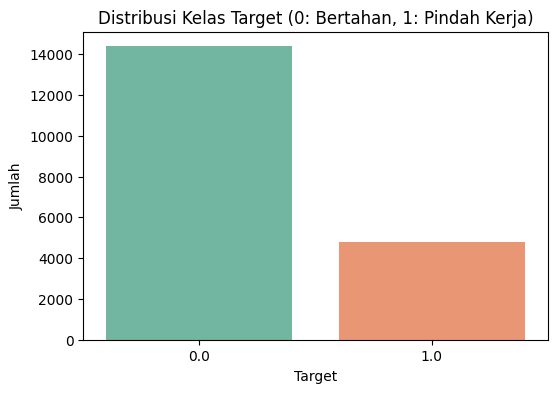


Persentase Kelas Target:
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


In [52]:
# Cek informasi tipe data dan nilai yang kosong (Missing Values)
print("--- Informasi Dataset ---")
train_df.info()

print("\n--- Jumlah Data Kosong per Kolom ---")
print(train_df.isnull().sum())

# Visualisasi Distribusi Target (Penting untuk analisis Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train_df, palette='Set2')
plt.title('Distribusi Kelas Target (0: Bertahan, 1: Pindah Kerja)')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.show()

print("\nPersentase Kelas Target:")
print(train_df['target'].value_counts(normalize=True) * 100)

# Preprocessing Data

In [53]:
# 1. Memisahkan Fitur (X) dan Target/Label (y) menggunakan train_df
X = train_df.drop(columns=['enrollee_id', 'target'])
y = train_df['target']

# 2. Mengelompokkan kolom berdasarkan karakteristik tipe datanya
numerical_cols = ['city_development_index', 'training_hours']
categorical_cols = [
    'city', 'gender', 'relevent_experience', 'enrolled_university', 
    'education_level', 'major_discipline', 'experience', 
    'company_size', 'company_type', 'last_new_job'
]

# 3. Membuat Pipeline Transformasi Data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Menggabungkan seluruh komponen preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Mengeksekusi rangkaian preprocessing
X_processed = preprocessor.fit_transform(X)
print(f"Dimensi data setelah Preprocessing Lengkap: {X_processed.shape}")

Dimensi data setelah Preprocessing Lengkap: (19158, 186)


# Pembagian Data (Data Splitting Menjadi Training Set dan Testing Set)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Sampel Data Training : {X_train.shape[0]}")
print(f"Jumlah Sampel Data Testing  : {X_test.shape[0]}")

Jumlah Sampel Data Training : 15326
Jumlah Sampel Data Testing  : 3832


# Hyperparameter Tuning (Pencarian Nilai K Optimal Menggunakan Grafik Akurasi)

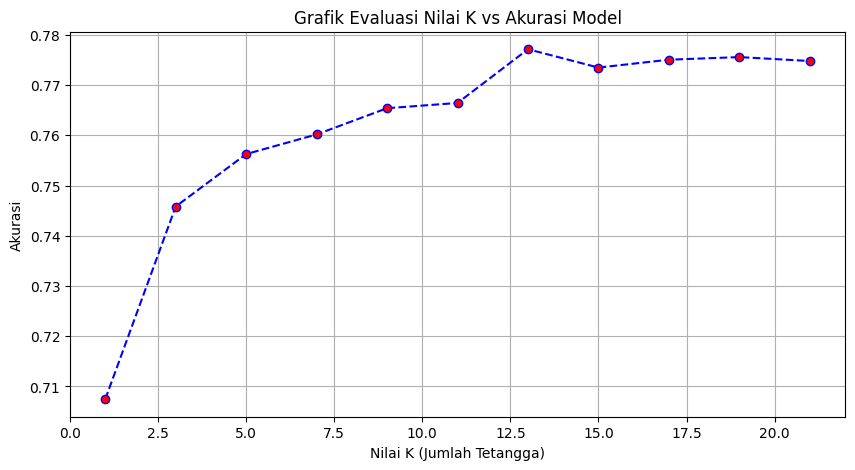


Hasil Tuning: Nilai K terbaik yang didapatkan adalah K = 13


In [55]:
error_rate = []
accuracy_list = []

for i in range(1, 22, 2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    
    error_rate.append(np.mean(pred_i != y_test))
    accuracy_list.append(accuracy_score(y_test, pred_i))

# Membuat grafik visualisasi performa Nilai K
plt.figure(figsize=(10, 5))
plt.plot(range(1, 22, 2), accuracy_list, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
plt.title('Grafik Evaluasi Nilai K vs Akurasi Model')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Akurasi')
plt.grid(True)
plt.show()

# Memilih K terbaik secara otomatis
best_k = range(1, 22, 2)[np.argmax(accuracy_list)]
print(f"\nHasil Tuning: Nilai K terbaik yang didapatkan adalah K = {best_k}")

# Pemodelan Akhir k-NN dan Evaluasi Performa Model

=== EVALUASI PERFORMA MODEL FINAL (K=13) ===
Akurasi Akhir: 77.71%

--- Classification Report ---
              precision    recall  f1-score   support

Bertahan (0)       0.83      0.89      0.86      2877
  Pindah (1)       0.57      0.45      0.50       955

    accuracy                           0.78      3832
   macro avg       0.70      0.67      0.68      3832
weighted avg       0.76      0.78      0.77      3832



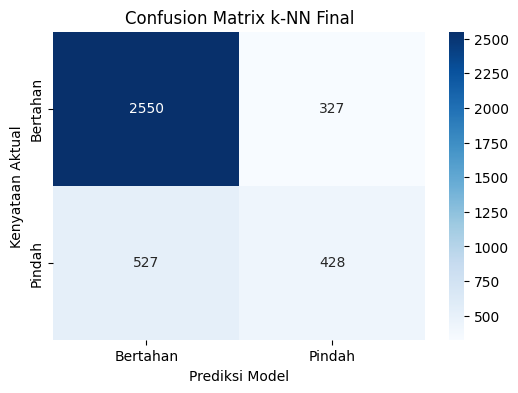


Nilai ROC-AUC Score: 0.7780


In [56]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

y_pred = knn_final.predict(X_test)
y_pred_proba = knn_final.predict_proba(X_test)[:, 1]

print(f"=== EVALUASI PERFORMA MODEL FINAL (K={best_k}) ===")
print(f"Akurasi Akhir: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Bertahan (0)', 'Pindah (1)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bertahan', 'Pindah'], yticklabels=['Bertahan', 'Pindah'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.title('Confusion Matrix k-NN Final')
plt.show()

# Menghitung Nilai ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nNilai ROC-AUC Score: {roc_auc:.4f}")

# Menyimpan Model 

In [61]:
import os
import joblib
import json
from sklearn.metrics import f1_score, roc_auc_score

# 1. Membuat folder 'models' jika belum ada
os.makedirs('../models', exist_ok=True)

# 2. Menyimpan Model k-NN Final
joblib.dump(knn_final, '../models/knn_model.pkl')

# 3. MENYIMPAN PREPROCESSOR PIPELINE (Wajib untuk kebutuhan Deployment/Web App!)
joblib.dump(preprocessor, '../models/preprocessor_knn.pkl')

# 4. Menyimpan nama fitur asli sebelum di-encode
feature_names_knn = X.columns.tolist()
joblib.dump(feature_names_knn, '../models/knn_selected_features.pkl')

# 5. Menyimpan konfigurasi parameter terbaik dalam format JSON
with open('../models/best_params_knn.json', 'w') as f:
    json.dump({
        'n_neighbors': int(knn_final.n_neighbors),
        'weights': str(knn_final.weights),
        'metric': str(knn_final.metric)
    }, f, indent=2)

# 6. Menyimpan Metadata Performa Model (Menggunakan variabel y_test & y_pred_proba)
joblib.dump({
    'n_features'   : X.shape[1],
    'feature_names': feature_names_knn,
    'model_version': 'KNN+Tuned',
    'auc'          : round(roc_auc_score(y_test, y_pred_proba), 4),
    'macro_f1'     : round(f1_score(y_test, y_pred, average='macro'), 2)
}, '../models/knn_metadata.pkl')

print("✅ KNN Model & Preprocessor Berhasil Tersimpan!")
print("Daftar File di Folder Models:", os.listdir('../models'))
print("-" * 50)

# 7. SANITY CHECK (Uji Coba 5 Data Pertama dari Test Set)
# Mengambil 5 sampel pertama dari array X_test dan y_test
sample = X_test[:5]
pred   = knn_final.predict(sample)
proba  = knn_final.predict_proba(sample)[:, 1]

# Menampilkan hasil komparasi prediksi ke dalam DataFrame agar rapi
result = pd.DataFrame({
    'Actual'      : y_test.iloc[:5].values,
    'Predicted'   : pred,
    'Prob(Pindah)': proba.round(3)
})

print("\n=== SANITY CHECK KNN STABIL ===")
print(result)

✅ KNN Model & Preprocessor Berhasil Tersimpan!
Daftar File di Folder Models: ['best_params_knn.json', 'best_params_rf.json', 'knn_metadata.pkl', 'knn_model.pkl', 'knn_selected_features.pkl', 'model_metadata.pkl', 'preprocessor_knn.pkl', 'random_forest_model.pkl', 'selected_features.pkl']
--------------------------------------------------

=== SANITY CHECK KNN STABIL ===
   Actual  Predicted  Prob(Pindah)
0     0.0        0.0         0.000
1     1.0        0.0         0.462
2     0.0        0.0         0.077
3     1.0        0.0         0.000
4     1.0        0.0         0.385


In [65]:
# Suruh teman run ini di notebook KNN-nya
joblib.dump(preprocessor, '../models/knn_preprocessor.pkl')
print("✅ Preprocessor KNN tersimpan!")

✅ Preprocessor KNN tersimpan!
